In [1]:
# 1. تثبيت أداة كاجل
!pip install -q kaggle

# 2. رفع ملف الـ kaggle.json اللي نزلناه
from google.colab import files
print("ارفع ملف kaggle.json هنا:")
files.upload()

# 3. عمل فولدر مخفي ونقل الملف فيه وتأمين صلاحياته
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. تحميل الداتا مباشرة من كاجل لكولاب
!kaggle datasets download -d paultimothymooney/kermany2018

# 5. فك ضغط الداتا في فولدر جديد اسمه kermany2018_data
!unzip -q kermany2018.zip -d ./kermany2018_data

ارفع ملف kaggle.json هنا:


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/kermany2018
License(s): CC-BY-NC-SA-4.0
100% 10.8G/10.8G [00:59<00:00, 195MB/s]



In [3]:
# 1. تثبيت المكتبات الناقصة في كولاب الأول
!pip install -q lime shap

# 2. كود الـ Imports بتاعك زي ما هو بالظبط
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import cv2
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap
import gc
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading and Exploration

In [6]:
# 1. إعدادات رسم البياني والألوان (هتشتغل عادي جداً في كولاب)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

# 2. المتغيرات الأساسية للموديل
IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 32
EPOCHS = 20

# 3. تعديل المسار ليبص على الفولدر الجديد في كولاب (بدل كاجل)
DATA_DIR = "./kermany2018_data/OCT2017 /train"
CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

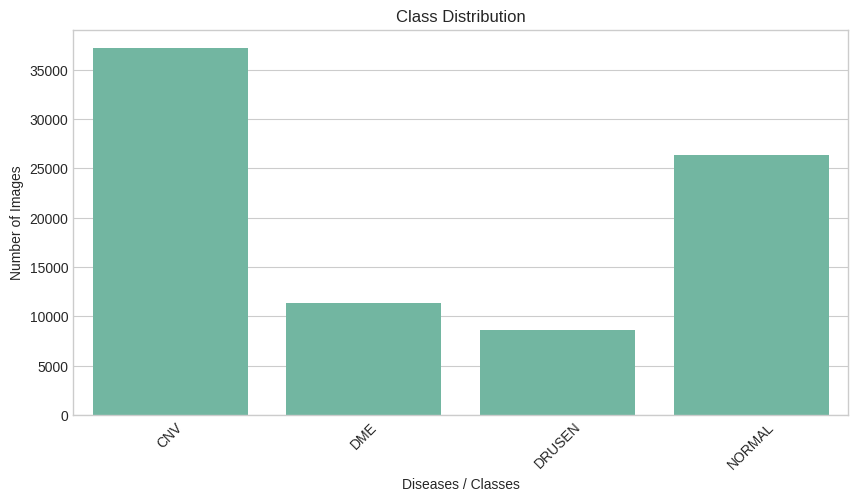

In [8]:
class_counts = {}

# تعديل المتغيرات لحروف كبيرة (CLASSES و DATA_DIR) عشان تطابق السيل اللي فاتت
for cls in CLASSES:
    class_dir = os.path.join(DATA_DIR, cls)
    if os.path.exists(class_dir):
        class_counts[cls] = len(os.listdir(class_dir))
    else:
        class_counts[cls] = 0
        print(f"تنبيه: الفولدر ده مش موجود: {class_dir}")

# رسم المخطط البياني لتوزيع الصور
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Diseases / Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

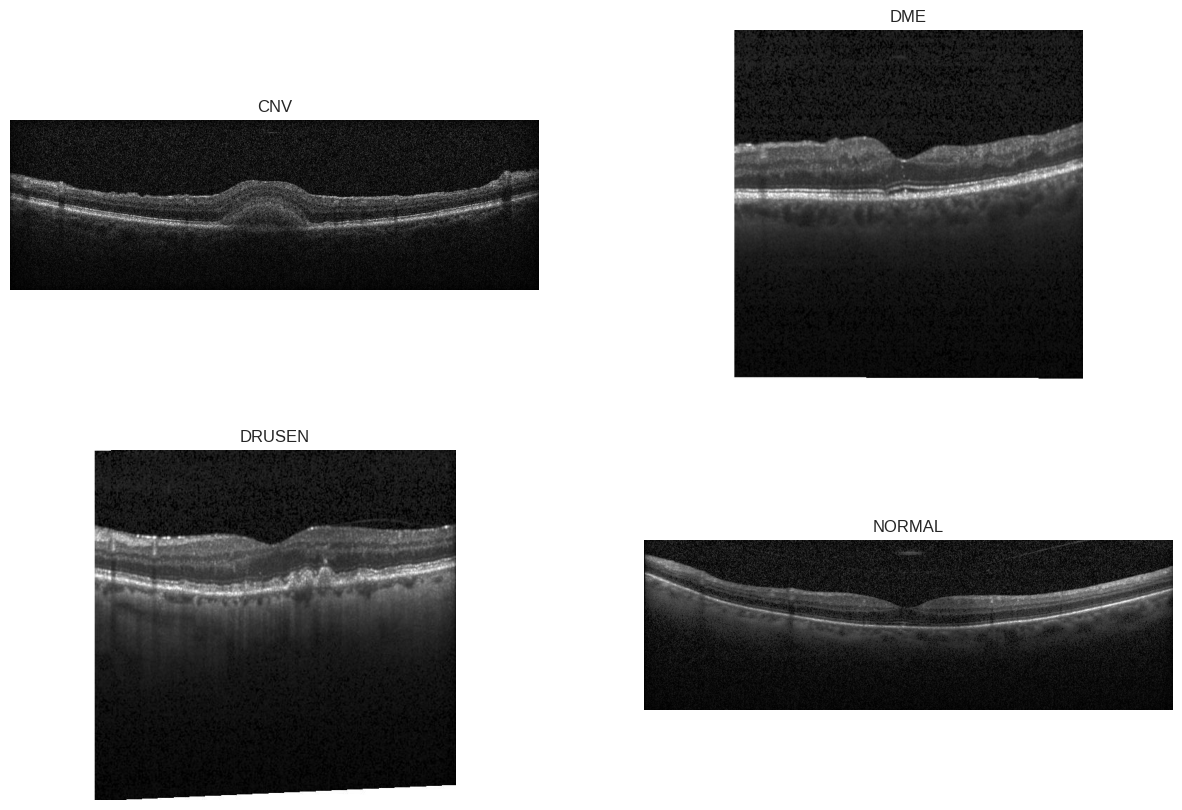

In [10]:
plt.figure(figsize=(15, 10))

# تعديل المتغيرات لحروف كبيرة (CLASSES و DATA_DIR)
for i, cls in enumerate(CLASSES):
    class_dir = os.path.join(DATA_DIR, cls)

    # التأكد إن الفولدر موجود وفيه صور فعلاً قبل ما نقرأ أول صورة
    if os.path.exists(class_dir) and len(os.listdir(class_dir)) > 0:
        img_path = os.path.join(class_dir, os.listdir(class_dir)[0])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    else:
        print(f"تنبيه: مفيش صور في الفولدر ده أو الفولدر مش موجود: {class_dir}")

plt.show()

# Data Preparation and Augmentation

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    classes=CLASSES
)

validation_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True,
    classes=CLASSES
)

test_generator = test_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    classes=CLASSES
)

Found 66788 images belonging to 4 classes.
Found 16696 images belonging to 4 classes.
Found 0 images belonging to 4 classes.


# CNN Model

In [12]:
def cnn_model():
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(256, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(len(CLASSES), activation='softmax')
    ])

    return model

model = cnn_model()

# Model Summary and Visualization

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 58, 58, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,409,188 (13.01 MB)

 Trainable params: 3,405,732 (12.99 MB)

 Non-trainable params: 3,456 (13.50 KB)

In [14]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.7 MB/s eta 0:00:00


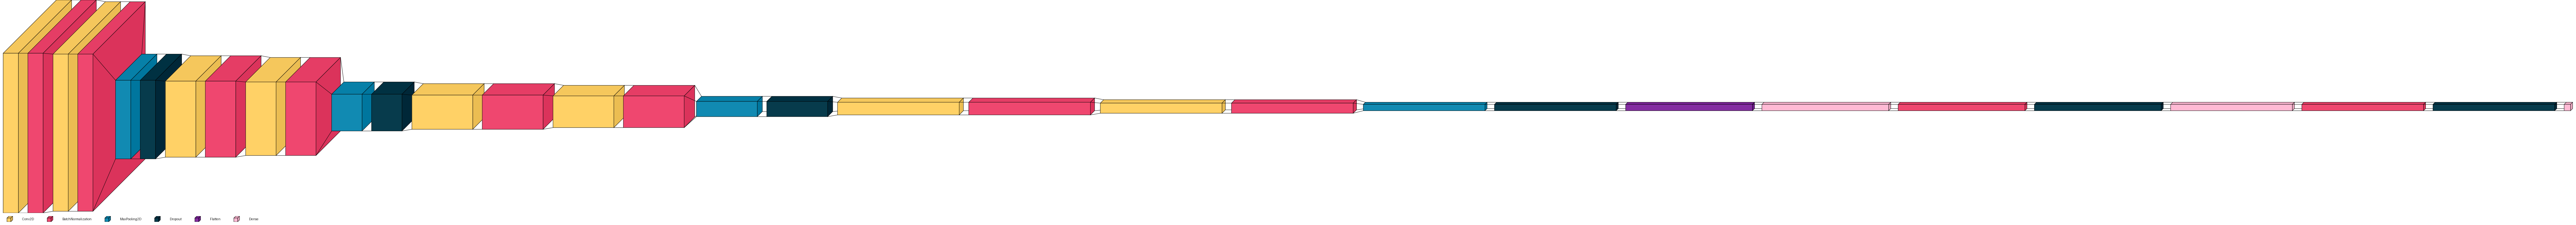

In [18]:
# 1. إجبار تينسورفلو على استخدام Keras 2 Backend (لازم يتكتب قبل الـ import بتاع visualkeras)
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

# 2. إعادة بناء الموديل برمجياً لربط الأبعاد
import tensorflow as tf
from tensorflow.keras.layers import Input

# تعديل بسيط عشان الـ output_shape يتفعل يدوي جوه الـ layers
for layer in model.layers:
    if not hasattr(layer, 'output_shape'):
        try:
            layer.output_shape = layer.output.shape
        except:
            pass

# 3. تشغيل الرسم المجسم الآن
import visualkeras
visualkeras.layered_view(
    model,
    to_file='./model_3d.png',
    legend=True,
    draw_volume=True,
    spacing=30
)

# 4. عرض الصورة المجسمة
from IPython.display import display
from PIL import Image
display(Image.open('./model_3d.png'))

In [19]:
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 30:
        lr *= 0.5e-3
    elif epoch > 25:
        lr *= 1e-3
    elif epoch > 20:
        lr *= 1e-2
    elif epoch > 10:
        lr *= 1e-1
    return lr

In [20]:
optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

In [21]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_oct_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

callbacks = [early_stopping, reduce_lr, model_checkpoint, lr_scheduler]

# Model Training

In [23]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

model.save('oct_classification_model.h5')

Epoch 1/20
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.8296 - auc: 0.9568 - loss: 0.9749 - precision: 0.8501 - recall: 0.8045
Epoch 1: val_accuracy improved from None to 0.86780, saving model to best_oct_model.h5



Epoch 1: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 654s 314ms/step - accuracy: 0.8408 - auc: 0.9604 - loss: 0.8870 - precision: 0.8594 - recall: 0.8187 - val_accuracy: 0.8678 - val_auc: 0.9717 - val_loss: 0.7448 - val_precision: 0.8841 - val_recall: 0.8503 - learning_rate: 0.0010
Epoch 2/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:24 69ms/step - accuracy: 0.8438 - auc: 0.9497 - loss: 0.8805 - precision: 0.8333 - recall: 0.7812
Epoch 2: val_accuracy improved from 0.86780 to 0.86810, saving model to best_oct_model.h5



Epoch 2: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 109s 52ms/step - accuracy: 0.8438 - auc: 0.9497 - loss: 0.8805 - precision: 0.8333 - recall: 0.7812 - val_accuracy: 0.8681 - val_auc: 0.9713 - val_loss: 0.7464 - val_precision: 0.8831 - val_recall: 0.8517 - learning_rate: 0.0010
Epoch 3/20
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8491 - auc: 0.9632 - loss: 0.7868 - precision: 0.8668 - recall: 0.8312
Epoch 3: val_accuracy did not improve from 0.86810
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 639s 306ms/step - accuracy: 0.8533 - auc: 0.9649 - loss: 0.7783 - precision: 0.8704 - recall: 0.8353 - val_accuracy: 0.8481 - val_auc: 0.9634 - val_loss: 0.8111 - val_precision: 0.8797 - val_recall: 0.8117 - learning_rate: 0.0010
Epoch 4/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:44 79ms/step - accuracy: 0.9375 - auc: 0.9888 - loss: 0.6018 - precision: 0.9375 - recall: 0.9375
Epoch 4: val_accuracy did not improve from 0.86810
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 107s 51ms/


Epoch 7: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 612s 293ms/step - accuracy: 0.8598 - auc: 0.9665 - loss: 0.7675 - precision: 0.8769 - recall: 0.8423 - val_accuracy: 0.8765 - val_auc: 0.9733 - val_loss: 0.7026 - val_precision: 0.8894 - val_recall: 0.8634 - learning_rate: 0.0010
Epoch 8/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:20 68ms/step - accuracy: 0.9062 - auc: 0.9954 - loss: 0.5154 - precision: 0.9355 - recall: 0.9062
Epoch 8: val_accuracy improved from 0.87650 to 0.87938, saving model to best_oct_model.h5



Epoch 8: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 108s 52ms/step - accuracy: 0.9062 - auc: 0.9954 - loss: 0.5154 - precision: 0.9355 - recall: 0.9062 - val_accuracy: 0.8794 - val_auc: 0.9747 - val_loss: 0.6931 - val_precision: 0.8942 - val_recall: 0.8661 - learning_rate: 0.0010
Epoch 9/20
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8658 - auc: 0.9686 - loss: 0.7269 - precision: 0.8814 - recall: 0.8481
Epoch 9: val_accuracy did not improve from 0.87938
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 622s 298ms/step - accuracy: 0.8662 - auc: 0.9690 - loss: 0.7198 - precision: 0.8811 - recall: 0.8490 - val_accuracy: 0.8630 - val_auc: 0.9668 - val_loss: 0.7347 - val_precision: 0.8787 - val_recall: 0.8471 - learning_rate: 0.0010
Epoch 10/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:51 82ms/step - accuracy: 0.8750 - auc: 0.9696 - loss: 0.7304 - precision: 0.9000 - recall: 0.8438
Epoch 10: val_accuracy did not improve from 0.87938
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 108s 52m


Epoch 13: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 623s 298ms/step - accuracy: 0.9030 - auc: 0.9815 - loss: 0.5183 - precision: 0.9126 - recall: 0.8939 - val_accuracy: 0.9245 - val_auc: 0.9875 - val_loss: 0.4200 - val_precision: 0.9307 - val_recall: 0.9197 - learning_rate: 1.0000e-04
Epoch 14/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:29 72ms/step - accuracy: 0.9375 - auc: 0.9974 - loss: 0.3323 - precision: 0.9355 - recall: 0.9062
Epoch 14: val_accuracy improved from 0.92454 to 0.92466, saving model to best_oct_model.h5



Epoch 14: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 109s 52ms/step - accuracy: 0.9375 - auc: 0.9974 - loss: 0.3323 - precision: 0.9355 - recall: 0.9062 - val_accuracy: 0.9247 - val_auc: 0.9873 - val_loss: 0.4223 - val_precision: 0.9302 - val_recall: 0.9188 - learning_rate: 1.0000e-04
Epoch 15/20
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9109 - auc: 0.9842 - loss: 0.4418 - precision: 0.9176 - recall: 0.9042
Epoch 15: val_accuracy improved from 0.92466 to 0.93636, saving model to best_oct_model.h5



Epoch 15: finished saving model to best_oct_model.h5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 625s 300ms/step - accuracy: 0.9120 - auc: 0.9846 - loss: 0.4294 - precision: 0.9188 - recall: 0.9057 - val_accuracy: 0.9364 - val_auc: 0.9908 - val_loss: 0.3520 - val_precision: 0.9433 - val_recall: 0.9305 - learning_rate: 1.0000e-04
Epoch 16/20
   1/2087 ━━━━━━━━━━━━━━━━━━━━ 2:21 68ms/step - accuracy: 0.9062 - auc: 0.9971 - loss: 0.2898 - precision: 0.9062 - recall: 0.9062
Epoch 16: val_accuracy did not improve from 0.93636
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 108s 52ms/step - accuracy: 0.9062 - auc: 0.9971 - loss: 0.2898 - precision: 0.9062 - recall: 0.9062 - val_accuracy: 0.9347 - val_auc: 0.9909 - val_loss: 0.3536 - val_precision: 0.9407 - val_recall: 0.9289 - learning_rate: 1.0000e-04
Epoch 17/20
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.9162 - auc: 0.9855 - loss: 0.3976 - precision: 0.9224 - recall: 0.9099
Epoch 17: val_accuracy did not improve from 0.93636
2087/2087 ━━━━━━━━━━━━━━━━━━

# Model Evaluation and Visualization

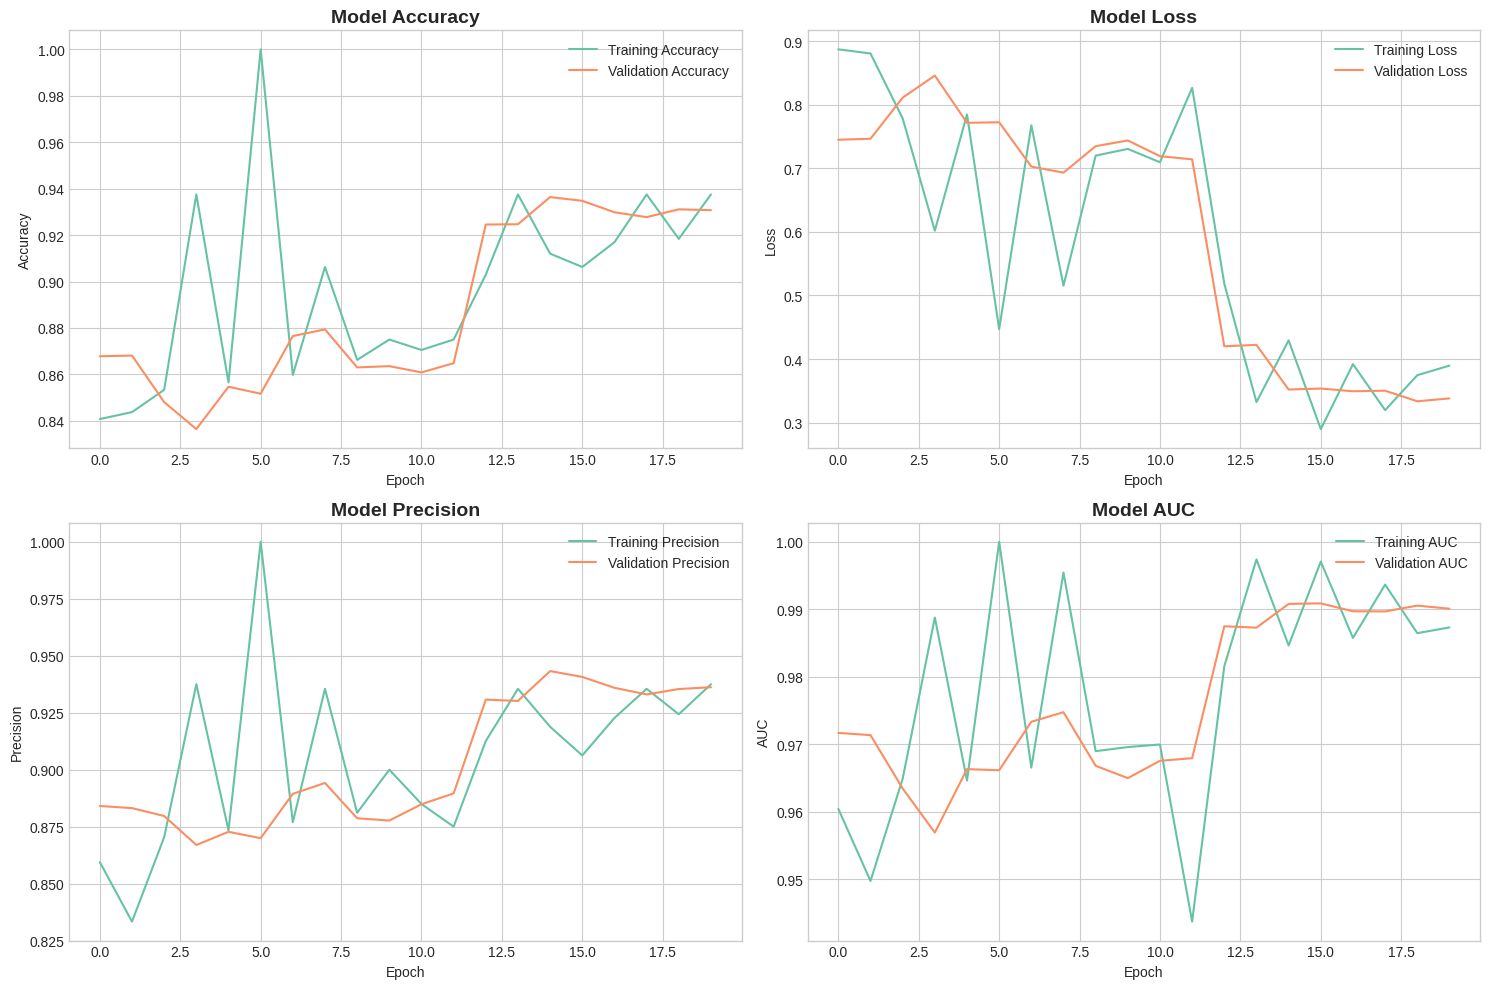

In [24]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0, 0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()

    axes[0, 1].plot(history.history['loss'], label='Training Loss')
    axes[0, 1].plot(history.history['val_loss'], label='Validation Loss')
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()

    axes[1, 0].plot(history.history['precision'], label='Training Precision')
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1, 0].set_title('Model Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()

    axes[1, 1].plot(history.history['auc'], label='Training AUC')
    axes[1, 1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1, 1].set_title('Model AUC', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

In [25]:
test_loss, test_accuracy, test_precision, test_recall, test_auc = model.evaluate(validation_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {test_auc:.4f}")

522/522 ━━━━━━━━━━━━━━━━━━━━ 110s 210ms/step - accuracy: 0.9308 - auc: 0.9905 - loss: 0.3356 - precision: 0.9358 - recall: 0.9267
Test Accuracy: 0.9308
Test Precision: 0.9358
Test Recall: 0.9267
Test AUC: 0.9905


جاري حساب التوقعات لـ Confusion Matrix...
522/522 ━━━━━━━━━━━━━━━━━━━━ 115s 218ms/step


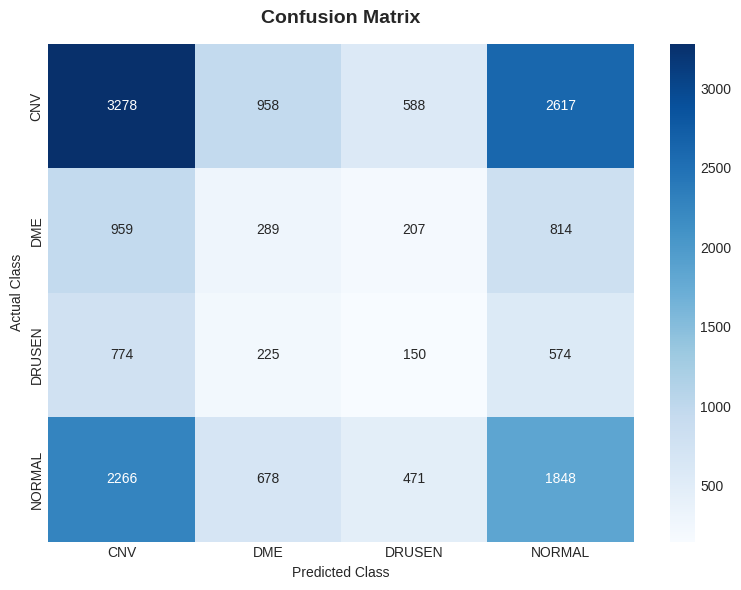

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# حساب التوقعات لبيانات التحقق
print("جاري حساب التوقعات لـ Confusion Matrix...")
validation_generator.reset()

y_pred_probs = model.predict(validation_generator, steps=len(validation_generator))
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = validation_generator.classes

# حساب ورسم المصفوفة
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.savefig('./confusion_matrix.png', dpi=300)
plt.show()

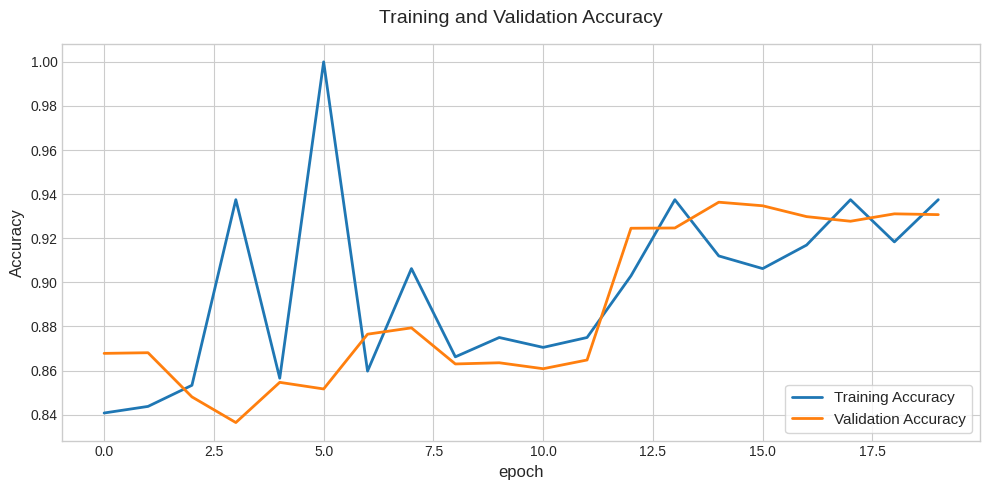

In [27]:
import matplotlib.pyplot as plt

# إعداد الستايل الأبيض النظيف
plt.style.use('seaborn-v0_8-whitegrid')

# رسم الـ Training and Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2)
plt.title('Training and Validation Accuracy', fontsize=14, pad=15)
plt.xlabel('epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig('./accuracy_curve.png', dpi=300)
plt.show()

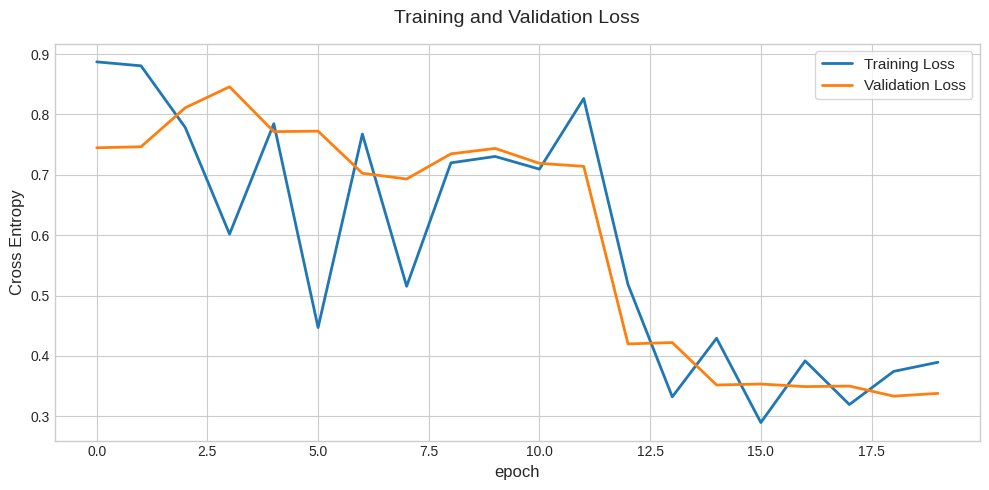

In [28]:
import matplotlib.pyplot as plt

# إعداد الستايل الأبيض النظيف
plt.style.use('seaborn-v0_8-whitegrid')

# رسم الـ Training and Validation Loss (Cross Entropy)
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
plt.title('Training and Validation Loss', fontsize=14, pad=15)
plt.xlabel('epoch', fontsize=12)
plt.ylabel('Cross Entropy', fontsize=12)
plt.legend(loc='upper right', frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig('./loss_curve.png', dpi=300)
plt.show()

جاري حساب البيانات لرسم منحنى ROC...
522/522 ━━━━━━━━━━━━━━━━━━━━ 106s 204ms/step


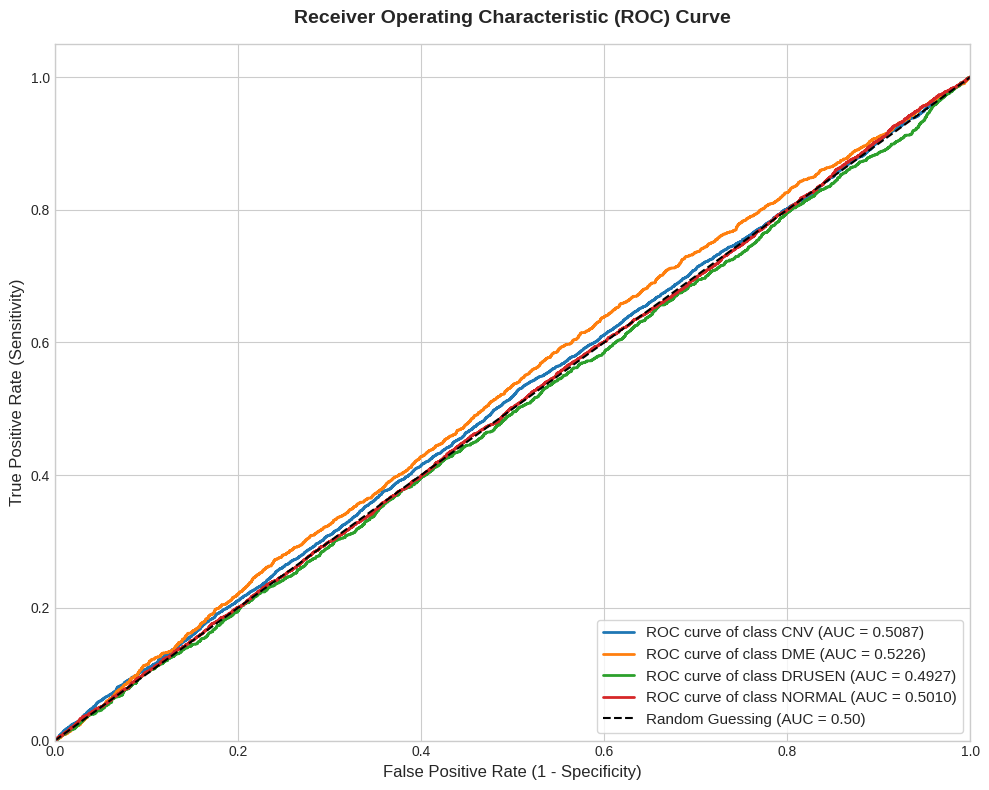

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

# 1. الحصول على التوقعات والـ Labels الحقيقية
print("جاري حساب البيانات لرسم منحنى ROC...")
validation_generator.reset()

y_pred_probs = model.predict(validation_generator, steps=len(validation_generator))
y_true = validation_generator.classes

# 2. تحويل الـ Labels لنظام الـ Binary (One-vs-Rest) عشان الـ ROC يفهمها
lb = LabelBinarizer()
y_true_binarized = lb.fit_transform(y_true)
n_classes = len(CLASSES)

# 3. إعداد الرسم البياني والستايل
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 8))

# ألوان مميزة لكل كلاس
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 4. حساب ورسم كيرف الـ ROC لكل كلاس
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_binarized[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=colors[i],
        lw=2,
        label=f'ROC curve of class {CLASSES[i]} (AUC = {roc_auc:.4f})'
    )

# 5. رسم خط المقارنة العشوائي (Random Guess Line)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Guessing (AUC = 0.50)')

# 6. تظبيط محاور الرسمة والـ Labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", frameon=True, fontsize=11)
plt.tight_layout()

# 7. حفظ الصورة بجودة عالية للتقرير
plt.savefig('./roc_curve.png', dpi=300)
plt.show()